* делите датасет на обучающую, валидационную и тестовую выборки со стратификацией в пропорции 60/20/20.
* В качестве целевой переменной используйте атрибут topic
* Обучите word2vec-эмбеддинги с помощью библиотеки gensim - 2 балла
* создайте модель для обучения на ваших данных, опишите, какими значениями вы инициализировали гиперпараметры модели, и почему
* визуально оцените внутреннее (intrinsic) качество получившихся эмбеддингов, используя методы gensim - doesnt_match, most_similar
* Загрузите предобученные эмбеддинги из navec и rusvectores (на ваш вкус) - 1 балл
* Обучите модель sklearn.linear_model.LogisticRegression с тремя вариантами векторизации текстов и сравните их качество между собой на валидационной выборке: 2 балла
* ваши эмбеддинги w2v
* предобученные эмбеддинги navec
* предобученные эмбеддинги rusvectores

* Попробуйте улучшить качество модели, взяв для ее обучения лучший набор эмбеддингов и используя его с взвешиванием через tf-idf.
* То есть, необходимо каждый текст представить в виде взвешенного усреднения эмбеддингов его слов, где весами являются соответствующие коэффициенты tf-idf.
* Финально сравните качество всех моделей на тестовой выборке - 1 балл

Общее
* Принимаемые решения обоснованы (почему выбрана определенная архитектура/гиперпараметр/оптимизатор/преобразование и т.п.) - 1 балл
* Обеспечена воспроизводимость решения: зафиксированы random_state, ноутбук воспроизводится от начала до конца без ошибок - 1 балл

In [1]:
%%capture cell
!pip install --upgrade pip
!pip install pandas corus natasha pandarallel requests beautifulsoup4 razdel numpy scikit-learn pymorphy3 gensim
!python -m nltk.downloader stopwords

In [33]:
!pip install gensim

In [31]:
!pip install navec

In [32]:
!pip install rusvectores

ERROR: Could not find a version that satisfies the requirement rusvectores (from versions: none)
ERROR: No matching distribution found for rusvectores


In [21]:
%%capture cell
!wget https://github.com/yutkin/Lenta.Ru-News-Dataset/releases/download/v1.0/lenta-ru-news.csv.gz

In [3]:
import pandas as pd
import corus
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, accuracy_score
import numpy as np
import re
from pymorphy3 import MorphAnalyzer
from nltk.corpus import stopwords
import nltk
from pandarallel import pandarallel
from tqdm import tqdm
import io
from gensim.models import Word2Vec
from gensim.models.phrases import Phrases
import matplotlib.pyplot as plt
from gensim.models.keyedvectors import KeyedVectors
from sklearn.decomposition import PCA

In [4]:
RANDOM_STATE = 2023
MIN_SAMPLES = 250

nltk.download('stopwords')
russian_stopwords = stopwords.words('russian')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [22]:
path = 'lenta-ru-news.csv.gz'
records = list(corus.load_lenta(path))
records[0]

LentaRecord(
    url='https://lenta.ru/news/2018/12/14/cancer/',
    title='Названы регионы России с\xa0самой высокой смертностью от\xa0рака',
    text='Вице-премьер по социальным вопросам Татьяна Голикова рассказала, в каких регионах России зафиксирована наиболее высокая смертность от рака, сообщает РИА Новости. По словам Голиковой, чаще всего онкологические заболевания становились причиной смерти в Псковской, Тверской, Тульской и Орловской областях, а также в Севастополе. Вице-премьер напомнила, что главные факторы смертности в России — рак и болезни системы кровообращения. В начале года стало известно, что смертность от онкологических заболеваний среди россиян снизилась впервые за три года. По данным Росстата, в 2017 году от рака умерли 289 тысяч человек. Это на 3,5 процента меньше, чем годом ранее.',
    topic='Россия',
    tags='Общество',
    date=None
)

In [23]:
#TODO Заморочиться и сделать так чтобы классы были разные и равное кол-во по 10к
df = pd.DataFrame(records)
df = df[[1, 2, 3]]
df = df.sample(n=100_000, random_state=RANDOM_STATE)
print(len(df))
df.head()

100000


,1,2,3
219508,С 2016 года в Москве будут возводиться дома но...,Финальное рассмотрение архитектурных концепций...,Дом
509251,Фонд OLPC анонсировал заводной ноутбук нового ...,"Фонд OLPC, целью которого является поставка лэ...",Наука и техника
335133,Катрин Денев получит премию Чаплина,Катрин Денев стала лауреатом премии имени Чарл...,Культура
272932,Россия испытает «донную» баллистическую ракету,Летом 2013 года в Белом море начнутся заводски...,Силовые структуры
114978,Россияне назвали атомную энергетику альтернати...,"Более 42 процентов россиян считают, что атомна...",Бизнес


Удалим редкие классы


In [ ]:
df[3].value_counts()

,count
3,
Россия,21742
Мир,18573
Экономика,10790
Спорт,8677
Бывший СССР,7189
Культура,7147
Наука и техника,7113
Интернет и СМИ,6007
Из жизни,3819


In [27]:
df = df.groupby(3).filter(lambda x: len(x) >= MIN_SAMPLES)
df[3].value_counts()

,count
3,
Россия,21742
Мир,18573
Экономика,10790
Спорт,8677
Бывший СССР,7189
Культура,7147
Наука и техника,7113
Интернет и СМИ,6007
Из жизни,3819


In [28]:
df = df.reset_index(drop=True)
df

,1,2,3
0,С 2016 года в Москве будут возводиться дома но...,Финальное рассмотрение архитектурных концепций...,Дом
1,Фонд OLPC анонсировал заводной ноутбук нового ...,"Фонд OLPC, целью которого является поставка лэ...",Наука и техника
2,Катрин Денев получит премию Чаплина,Катрин Денев стала лауреатом премии имени Чарл...,Культура
3,Россия испытает «донную» баллистическую ракету,Летом 2013 года в Белом море начнутся заводски...,Силовые структуры
4,Россияне назвали атомную энергетику альтернати...,"Более 42 процентов россиян считают, что атомна...",Бизнес
...,...,...,...
99632,В Москве скончался актер Геннадий Корольков,В Москве в возрасте 66 лет скончался известный...,Культура
99633,Casadei посвятил новую коллекцию эпохе диско,Итальянская марка Casadei представила коллекци...,Ценности
99634,Киев в очередной раз возмутился поездкой Путин...,Киев заявил решительный протест МИД России в с...,Бывший СССР
99635,Коммунисты предложили вынести вопрос о пенсион...,В КПРФ предложили провести референдум о повыше...,Россия


In [ ]:
morph = MorphAnalyzer()
tqdm.pandas()

#Упростил процесс предобратки по сравнению с hw_1
def preprocess_text(text):
    text = re.sub(r'[^а-яё\s-]', ' ', str(text).lower(), flags=re.IGNORECASE)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = [
        word for word in text.split()
        if len(word) > 2
        and word not in russian_stopwords
    ]
    lemmas = [
        morph.parse(word)[0].normal_form
        for word in tokens
    ]
    return ' '.join(lemmas)

df['processed_text'] = (df[1] + ' ' + df[2]).progress_apply(preprocess_text)
df['topic'] = df[3].str.lower().str.replace(r'\s+', ' ', regex=True).str.strip()


X = df['processed_text']
y = df['topic']

df = df[['processed_text', 'topic']]

100%|██████████| 99637/99637 [30:32<00:00, 54.38it/s]


In [ ]:
df

,processed_text,topic
0,год москва быть возводиться дом новый серия фи...,дом
1,фонд анонсировать заводной ноутбук новый покол...,наука и техника
2,катрин денев получить премия чаплин катрин ден...,культура
3,россия испытать донный баллистический ракета л...,силовые структуры
4,россиянин назвать атомный энергетика альтернат...,бизнес
...,...,...
99632,москва скончаться актёр геннадий корольков мос...,культура
99633,посвятить новый коллекция эпоха диско итальянс...,ценности
99634,киев очередной возмутиться поездка путин крым ...,бывший ссср
99635,коммунист предложить вынести вопрос пенсионный...,россия


In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.4,
    stratify=y,
    random_state=RANDOM_STATE
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=RANDOM_STATE
)

print(f"Обучающая выборка: {len(X_train):,} примеров")
print(f"Валидационная выборка: {len(X_val):,} примеров")
print(f"Тестовая выборка: {len(X_test):,} примеров")

Обучающая выборка: 69,745 примеров
Валидационная выборка: 17,935 примеров
Тестовая выборка: 11,957 примеров


In [ ]:
df.to_csv('lenta-ru-new-ready-pipeline_hw2.csv', index=False, encoding='utf-8')

In [5]:
from google.colab import files
uploaded = files.upload()

Saving lenta-ru-new-ready-pipeline_hw2.csv to lenta-ru-new-ready-pipeline_hw2.csv


In [24]:
dfw2v = pd.read_csv(r'/content/lenta-ru-new-ready-pipeline_hw2.csv')

In [43]:
dfw2v

,processed_text,topic
0,год москва быть возводиться дом новый серия фи...,дом
1,фонд анонсировать заводной ноутбук новый покол...,наука и техника
2,катрин денев получить премия чаплин катрин ден...,культура
3,россия испытать донный баллистический ракета л...,силовые структуры
4,россиянин назвать атомный энергетика альтернат...,бизнес
...,...,...
99632,москва скончаться актёр геннадий корольков мос...,культура
99633,посвятить новый коллекция эпоха диско итальянс...,ценности
99634,киев очередной возмутиться поездка путин крым ...,бывший ссср
99635,коммунист предложить вынести вопрос пенсионный...,россия


 **Обучите word2vec-эмбеддинги с помощью библиотеки gensim - 2 балла
создайте модель для обучения на ваших данных, опишите, какими значениями вы инициализировали гиперпараметры модели, и почему**

In [44]:
X = dfw2v['processed_text']
y = dfw2v['topic']

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.4,
    stratify=y,
    random_state=RANDOM_STATE
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=RANDOM_STATE
)

print(f"Обучающая выборка: {len(X_train):,} примеров")
print(f"Валидационная выборка: {len(X_val):,} примеров")
print(f"Тестовая выборка: {len(X_test):,} примеров")

Обучающая выборка: 59,782 примеров
Валидационная выборка: 19,927 примеров
Тестовая выборка: 19,928 примеров


In [ ]:
sentences = [text.split() for text in X_train]

phrases = Phrases(sentences, min_count=50, threshold=50) #Биграммы. Объединяет устойчивые сочетания слов в единые токены: рассматриваем биграмы если встречаются чаще 50 раз и "порог интереса" 50 для объединения.
bigram = phrases.freeze()  # Фиксируем найденные биграммы
sentences_phrased = [bigram[sent] for sent in sentences]

params = {
    'vector_size': 300,      # Увеличенный размер для захвата семантики новостей, нашел такую рекомендацию где-то на сайте для текста содержащий новости ставим 300
    'window': 10,            # Широкий контекст для новостных материалов, учитывая формальный язык большинства новостей и их длинну, нужно сделать шире расстояние между текущим и предсказываемым словом
    'min_count': 15,         # Фильтр редких терминов, если на целом датасете в 99к слово встречается слишком редко, то и не стоит его векторизовать
    'workers': 8,            # Параллелизация для многоядерных процессоров
    'sg': 1,                 # используем Skip-Gram т.к. каждый отдельное слово в октнексте использует отдельный softmax, то есть модель пытается предсказать каждое контекстное слово отдельно
    'hs': 0,                 # Снижает вычислительную сложность и эффективнее для больших данных
    'negative': 15,          # Число negative примеров. Увеличивает разнообразие контрастных примеров для модели
    'alpha': 0.03,           # Начальная скорость обучения
    'min_alpha': 0.0001,     # Плавное снижение с каждой эпохой
    'epochs': 30,            # Много эпох, гарантирует что редкие слова хорошо будут определяться. #todo добавить поиск лучшей эпохи, если успею
    'sample': 1e-5,          # Снижает влияние слишком частых слов (например, "который", "также").
}

model = Word2Vec(**params)
model.build_vocab(sentences_phrased)
model.train(
    sentences_phrased,
    total_examples=model.corpus_count,
    epochs=model.epochs,
    report_delay=60
)

model.save("news_word2vec_optimized.model")


In [11]:
uploaded_model = files.upload()

In [12]:
# model = Word2Vec.load(uploaded_model)
model = Word2Vec.load("news_word2vec_optimized.model")
print("Вектор 'россия':", model.wv['россия'][:5])

Вектор 'россия': [-0.13853993  0.18202867  0.28353322  0.07264549  0.01010407]


Очень удивительно что китай и пекин, не та к близки, возможно мало новостей про китай. А вот остальные слова более менее находятся рядом.

И not_similar довольно хорошие показатели. Особенно яблоко. Но удивительно что денеженые средства не так уж далеко от погоды.

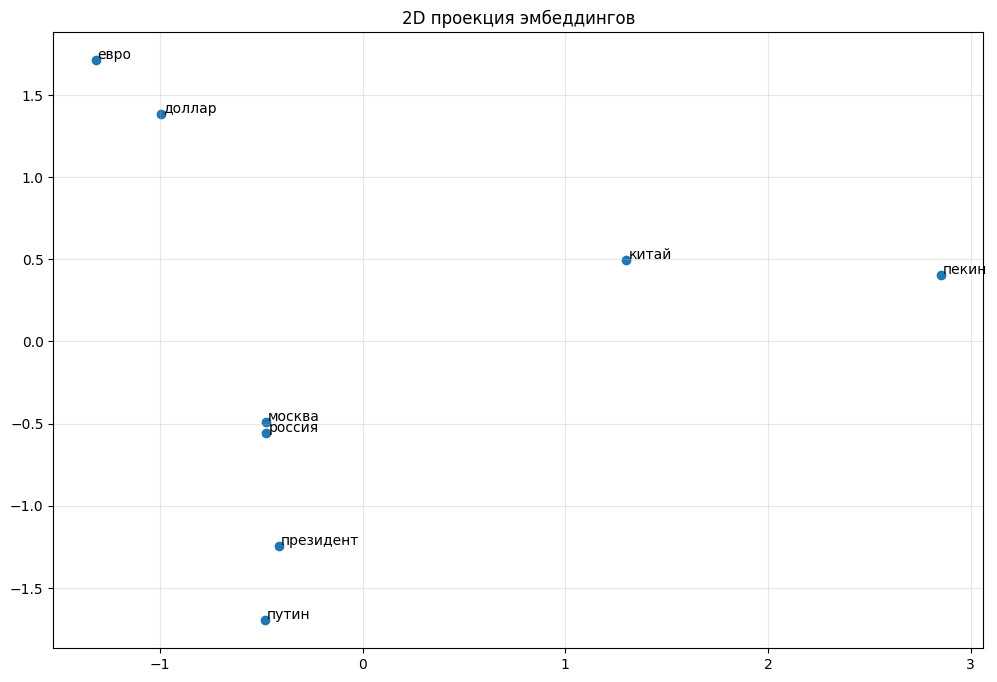

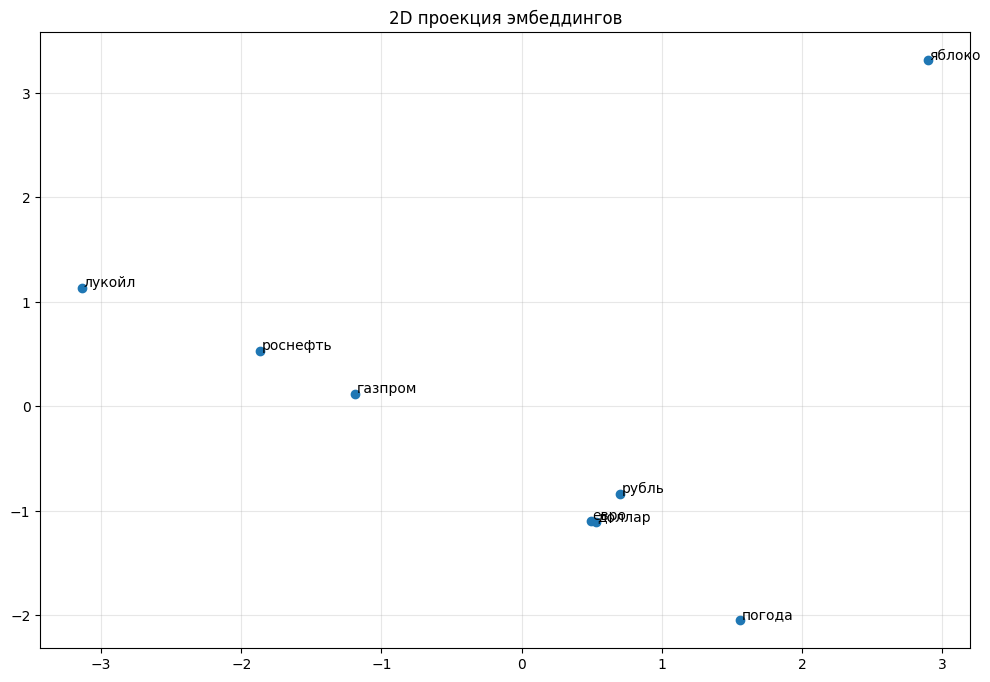

In [17]:
def plot_embeddings(model, words):
    vectors = np.array([model.wv[word] for word in words])
    pca = PCA(n_components=2)
    coords = pca.fit_transform(vectors)

    plt.figure(figsize=(12,8))
    plt.scatter(coords[:,0], coords[:,1])

    for i, word in enumerate(words):
        plt.annotate(word, (coords[i,0]+0.01, coords[i,1]+0.01))

    plt.title("2D проекция эмбеддингов")
    plt.grid(alpha=0.3)
    plt.show()

#Связанные слова most_similar
key_words = ['россия', 'москва', "китай", "пекин",
            'доллар', 'евро', 'путин', 'президент']

#Слова не связанные
key_word_doesnt_match = [
    "газпром", "лукойл", "яблоко", "роснефть",
    "доллар", "евро", "рубль", "погода"
]
plot_embeddings(model, key_words)
plot_embeddings(model, key_word_doesnt_match)

Есть пары, которые очень рядом находятся. Что показывает хорошую способность модели понимать контекст.

In [20]:
word_pairs = [
    ("россия", "москва"),
    ("доллар", "евро"),
    ("путин", "президент"),
    ("футбол", "теннис"),
    ("санкция", "экономика"),
    ("евро", "доллар")
]

for w1, w2 in word_pairs:
    if w1 in model.wv and w2 in model.wv:
        similarity = model.wv.similarity(w1, w2)
        print(f"Сходство между '{w1}' и '{w2}': {similarity:.3f}")
    print()

Сходство между 'россия' и 'москва': 0.600

Сходство между 'доллар' и 'евро': 0.622

Сходство между 'путин' и 'президент': 0.696

Сходство между 'футбол' и 'теннис': 0.390

Сходство между 'санкция' и 'экономика': 0.424

Сходство между 'евро' и 'доллар': 0.622



Обучите модель sklearn.linear_model.LogisticRegression с тремя вариантами векторизации текстов и сравните их качество между собой на валидационной выборке: 2 балла
ваши эмбеддинги w2v
предобученные эмбеддинги navec
предобученные эмбеддинги rusvectores


navec_news_v1_1B_250K_300d_100q.tar Испольщзуем эту модель т.к. у нее в соурсах lenta.ru и она меньше

In [36]:
!wget https://storage.yandexcloud.net/natasha-navec/packs/navec_hudlit_v1_12B_500K_300d_100q.tar

--2025-03-14 15:15:08--  https://storage.yandexcloud.net/natasha-navec/packs/navec_hudlit_v1_12B_500K_300d_100q.tar
Resolving storage.yandexcloud.net (storage.yandexcloud.net)... 213.180.193.243, 2a02:6b8::1d9
Connecting to storage.yandexcloud.net (storage.yandexcloud.net)|213.180.193.243|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 53012480 (51M) [application/x-tar]
Saving to: ‘navec_hudlit_v1_12B_500K_300d_100q.tar’

navec_hudlit_v1_12B 100%[===================>]  50.56M  15.6MB/s    in 3.5s    

2025-03-14 15:15:12 (14.5 MB/s) - ‘navec_hudlit_v1_12B_500K_300d_100q.tar’ saved [53012480/53012480]



Модель берем для новостей. Прямой ссылки не получилось найти. Поэтому загру

In [41]:
uploaded_model = files.upload()

Saving model.bin to model.bin


In [54]:
from navec import Navec
from gensim.models import KeyedVectors
from gensim.models import FastText

navec = Navec.load('/content/navec_hudlit_v1_12B_500K_300d_100q.tar')
rusvec = KeyedVectors.load_word2vec_format('model.bin', binary=True, unicode_errors='ignore')


In [55]:
# Функции векторизации
def vectorize_w2v(text):
    vectors = [model.wv[word] for word in text.split() if word in model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(300)

def vectorize_navec(text):
    vectors = [navec[word] for word in text.split() if word in navec]
    return np.mean(vectors, axis=0) if vectors else np.zeros(300)

def vectorize_rusvec(text):
    vectors = [rusvec[word] for word in text.split() if word in rusvec]
    return np.mean(vectors, axis=0) if vectors else np.zeros(300) #300 размерность эмбеддингов в моделях

# Векторизация данных
X_train_w2v = np.array([vectorize_w2v(text) for text in X_train])
X_val_w2v = np.array([vectorize_w2v(text) for text in X_val])
X_test_w2v = np.array([vectorize_w2v(text) for text in X_test])

X_train_navec = np.array([vectorize_navec(text) for text in X_train])
X_val_navec = np.array([vectorize_navec(text) for text in X_val])
X_test_navec = np.array([vectorize_navec(text) for text in X_test])

X_train_rusvec = np.array([vectorize_rusvec(text) for text in X_train])
X_val_rusvec = np.array([vectorize_rusvec(text) for text in X_val])
X_test_rusvec = np.array([vectorize_rusvec(text) for text in X_test])


 Мда. удивлен что базовый w2v хорошо отработал. Но с другой стороны другие модели не такие большие, хотя и заточены под новости. Т.к. точности более менее одинаковые. То Для NaVac и моей w2v сделаем TF-IDF, посмотрим и сравним

In [56]:
# Обучение и оценка моделей
def train_evaluate(X_train, X_val, model_name):
    lr = LogisticRegression(
        max_iter=1000,
        class_weight='balanced', # автоматически присваивает веса классам обратно пропорционально их частоте в класах, улучшает recall редких классов
        multi_class='multinomial', # Используется для не бинарной  классификации, также хорошо подходит для классов с большим кол-во примеров +1000
        solver='saga' # солвер оптимальный на больших данных
    )
    lr.fit(X_train, y_train)
    y_pred = lr.predict(X_val)

    print(f'\n=== {model_name} ===')
    print(f"Accuracy: {accuracy_score(y_val, y_pred):.3f}")
    print(classification_report(y_val, y_pred, zero_division=0))

# Сравнение всех методов
train_evaluate(X_train_w2v, X_val_w2v, 'Custom Word2Vec')
train_evaluate(X_train_navec, X_val_navec, 'NaVeс')
train_evaluate(X_train_rusvec, X_val_rusvec, 'RusVectores')

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



=== Custom Word2Vec ===
Accuracy: 0.753
                   precision    recall  f1-score   support

           бизнес       0.21      0.71      0.33       203
      бывший ссср       0.75      0.85      0.80      1438
              дом       0.72      0.85      0.78       588
         из жизни       0.49      0.69      0.57       764
   интернет и сми       0.69      0.71      0.70      1202
         культура       0.86      0.86      0.86      1429
              мир       0.84      0.75      0.79      3714
  наука и техника       0.82      0.77      0.79      1423
      путешествия       0.36      0.81      0.50       166
           россия       0.85      0.62      0.72      4348
силовые структуры       0.34      0.70      0.45       545
            спорт       0.97      0.96      0.96      1735
         ценности       0.70      0.87      0.78       214
        экономика       0.85      0.73      0.78      2158

         accuracy                           0.75     19927
        macro

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



=== NaVeс ===
Accuracy: 0.710
                   precision    recall  f1-score   support

           бизнес       0.17      0.65      0.27       203
      бывший ссср       0.69      0.79      0.74      1438
              дом       0.66      0.84      0.74       588
         из жизни       0.47      0.62      0.54       764
   интернет и сми       0.63      0.68      0.65      1202
         культура       0.83      0.84      0.84      1429
              мир       0.83      0.72      0.77      3714
  наука и техника       0.79      0.72      0.75      1423
      путешествия       0.28      0.80      0.41       166
           россия       0.83      0.55      0.66      4348
силовые структуры       0.27      0.65      0.39       545
            спорт       0.96      0.94      0.95      1735
         ценности       0.59      0.88      0.71       214
        экономика       0.82      0.69      0.75      2158

         accuracy                           0.71     19927
        macro avg      

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



=== RusVectores ===
Accuracy: 0.038
                   precision    recall  f1-score   support

           бизнес       0.00      0.00      0.00       203
      бывший ссср       0.00      0.00      0.00      1438
              дом       0.00      0.00      0.00       588
         из жизни       0.04      1.00      0.07       764
   интернет и сми       0.00      0.00      0.00      1202
         культура       0.00      0.00      0.00      1429
              мир       0.00      0.00      0.00      3714
  наука и техника       0.00      0.00      0.00      1423
      путешествия       0.00      0.00      0.00       166
           россия       0.00      0.00      0.00      4348
силовые структуры       0.00      0.00      0.00       545
            спорт       0.00      0.00      0.00      1735
         ценности       0.00      0.00      0.00       214
        экономика       0.00      0.00      0.00      2158

         accuracy                           0.04     19927
        macro avg

In [ ]:
tfidf = TfidfVectorizer(
    tokenizer=lambda x: x.split(),  # Токенизация по пробелам
    min_df=5,  # Слова, встречающиеся реже 5 раз, игнорируются
    max_features=100_000  # Максимальный размер словаря
)

tfidf.fit(X_train)

word_weights = defaultdict(
    lambda: 1.0,  # Вес по умолчанию для OOV-слов
    {word: tfidf.idf_[idx] for word, idx in tfidf.vocabulary_.items()}
)

In [ ]:
X_train,  y_train,

X_val, X_test, y_val, y_test

In [58]:
from sklearn.feature_extraction.text import TfidfVectorizer
from collections import defaultdict

In [61]:
tfidf = TfidfVectorizer(
    tokenizer=lambda x: x.split(),  #токенизация
    token_pattern=None,  # Игнорируем стандартный шаблон
)

# Обучаем на тренировочных данных
tfidf.fit(X_train)

#Создаем словарь {слово: idf вес}
word_weights = defaultdict(
    lambda: 1.0,  # Вес по умолчанию для OOV-слов
    {word: tfidf.idf_[idx] for word, idx in tfidf.vocabulary_.items()}
)

In [66]:
import numpy as np

def w2v_tfidf_vector(text):
    vectors = []
    total_weight = 0.0
    for word in text.split():
        try:
            # 1. Получаем вес слова
            weight = word_weights[word]
            # 2. Достаем вектор из модели
            vec = model.wv[word]
            # 3. Умножаем вектор на вес
            vectors.append(vec * weight)
            total_weight += weight
        except KeyError:  # Если слова нет в модели
            continue
    # 4. Усредняем с учетом весов
    return np.sum(vectors, axis=0) / total_weight if total_weight != 0 else np.zeros(300)



In [67]:
def navec_tfidf_vector(text):
    vectors = []
    total_weight = 0.0
    for word in text.split():
        try:
            weight = word_weights[word]
            vec = navec[word]
            vectors.append(vec * weight)
            total_weight += weight
        except KeyError:
            continue
    return np.sum(vectors, axis=0) / total_weight if total_weight !=0 else np.zeros(300)

In [65]:
# Для Custom Word2Vec
X_train_w2v_tfidf = np.array([w2v_tfidf_vector(text) for text in X_train])
X_val_w2v_tfidf = np.array([w2v_tfidf_vector(text) for text in X_val])
X_test_w2v_tfidf = np.array([w2v_tfidf_vector(text) for text in X_test])

# Для NaVeс
X_train_navec_tfidf = np.array([navec_tfidf_vector(text) for text in X_train])
X_val_navec_tfidf = np.array([navec_tfidf_vector(text) for text in X_val])
X_test_navec_tfidf = np.array([navec_tfidf_vector(text) for text in X_test])

In [68]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

def train_model(X_train, X_val, name):
    model = LogisticRegression(
        max_iter=2000,
        class_weight='balanced',
        multi_class='multinomial',
        solver='saga'
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    print(f"{name} Accuracy: {accuracy_score(y_val, y_pred):.3f}")
    return model

# Мой Word2Vec + TF-IDF
w2v_tfidf_model = train_model(X_train_w2v_tfidf, X_val_w2v_tfidf, "W2V + TF-IDF")

# NaVeс + TF-IDF
navec_tfidf_model = train_model(X_train_navec_tfidf, X_val_navec_tfidf, "NaVeс + TF-IDF")

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


W2V + TF-IDF Accuracy: 0.747


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


NaVeс + TF-IDF Accuracy: 0.699


In [ ]:
# Обучение и оценка моделей
def train_evaluate(X_train, X_val, model_name):
    lr = LogisticRegression(
        max_iter=1000,
        class_weight='balanced', # автоматически присваивает веса классам обратно пропорционально их частоте в класах, улучшает recall редких классов
        multi_class='multinomial', # Используется для не бинарной  классификации, также хорошо подходит для классов с большим кол-во примеров +1000
        solver='saga' # солвер оптимальный на больших данных
    )
    lr.fit(X_train, y_train)
    y_pred = lr.predict(X_val)

    print(f'\n=== {model_name} ===')
    print(f"Accuracy: {accuracy_score(y_val, y_pred):.3f}")
    print(classification_report(y_val, y_pred, zero_division=0))

# Сравнение всех методов
train_evaluate(X_train_w2v, X_val_w2v, 'Custom Word2Vec')
train_evaluate(X_train_navec, X_val_navec, 'NaVeс')
train_evaluate(X_train_rusvec, X_val_rusvec, 'RusVectores')

In [ ]:
def test_model(model, X_test, name):
    y_pred = model.predict(X_test)
    print(f"\n{name}")
    print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.3f}")
    print(classification_report(y_test, y_pred, zero_division=0))

# Обучение всех классификаторов
models = {
    "W2V Baseline": LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        multi_class='multinomial',
        solver='saga'
    ).fit(X_train_w2v, y_train),
    "W2V + TF-IDF": LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        multi_class='multinomial',
    ).fit(X_train_w2v_tfidf, y_train),
    "NaVeс Baseline": LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        multi_class='multinomial',
        solver='saga'
    ).fit(X_train_navec, y_train),
    "NaVeс + TF-IDF": LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        multi_class='multinomial',
        solver='saga'
    ).fit(X_train_navec_tfidf, y_train),
    "RusVectores": LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        multi_class='multinomial',
        solver='saga'
    ).fit(X_train_rusvec, y_train)
}



Получилось улучшить свою модель. Мне кажется просто датасет не очень разнообразный и navec и rusvec не смогли показать себя в полную силу. Но факт остается наша модель w2v tf-idf лучшая!

In [75]:
test_data_mapping = {
    "W2V Baseline": "X_test_w2v",
    "W2V + TF-IDF": "X_test_w2v_tfidf",
    "NaVeс Baseline": "X_test_navec",
    "NaVeс + TF-IDF": "X_test_navec_tfidf",
    "RusVectores": "X_test_rusvec"
}

for name, model in models.items():
      X_test_var = test_data_mapping[name]
      X_test_data = globals()[X_test_var]
      test_model(model, X_test_data, name)



W2V Baseline
Test Accuracy: 0.754
                   precision    recall  f1-score   support

           бизнес       0.22      0.69      0.33       203
      бывший ссср       0.77      0.86      0.81      1438
              дом       0.73      0.86      0.79       588
         из жизни       0.49      0.70      0.58       764
   интернет и сми       0.69      0.71      0.70      1201
         культура       0.86      0.86      0.86      1430
              мир       0.82      0.75      0.79      3715
  наука и техника       0.81      0.78      0.79      1422
      путешествия       0.34      0.84      0.48       166
           россия       0.87      0.62      0.72      4349
силовые структуры       0.34      0.69      0.46       545
            спорт       0.96      0.95      0.96      1736
         ценности       0.70      0.85      0.77       213
        экономика       0.85      0.73      0.78      2158

         accuracy                           0.75     19928
        macro avg  

-----
